# Flickr30k Baseline Training

This notebook trains a image-text retrieval baseline with:

- `ViT-Base` image encoder
- `BERT-base-uncased` text encoder
- linear projection heads
- symmetric InfoNCE loss
- validation with `Recall@1/10/20`

In [1]:
# Check environment
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no gpu")


2.10.0+cu128
True
NVIDIA A100-SXM4-40GB


In [2]:
!pip install -q datasets transformers pillow tqdm

In [3]:
# Set up the output directory for saving results
from pathlib import Path

USE_DRIVE = False
if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUTPUT_DIR = Path('/content/drive/MyDrive/ECE1508/baseline_outputs')
else:
    OUTPUT_DIR = Path('/content/baseline_outputs')

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR

PosixPath('/content/baseline_outputs')

In [4]:
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset
from torch.utils.data import DataLoader
from transformers import AutoModel, AutoTokenizer, ViTImageProcessor, ViTModel #BERT + ViT
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


In [5]:
# Set training hyperparameters and random seed
SEED = 42
BATCH_SIZE = 128
NUM_EPOCHS = 10
LR = 1e-4
WEIGHT_DECAY = 1e-4
PROJECTION_DIM = 256 # Dimension of shared embedding space
MAX_TEXT_LEN = 64 # Maximum number of tokens per text input
TEMPERATURE_INIT = 0.07 # temperature for loss scaling
FREEZE_BACKBONES = True # Whether to freeze pretrained encoders(BERT/ViT)

NUM_WORKERS = 4

random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [6]:
# Load the Flickr30k dataset (image-text pairs)
dataset = load_dataset('Zoe3324/flickr30k-pairs')
dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/657 [00:00<?, ?B/s]

data/train-00000-of-00012.parquet:   0%|          | 0.00/97.0M [00:00<?, ?B/s]

data/train-00001-of-00012.parquet:   0%|          | 0.00/96.2M [00:00<?, ?B/s]

data/train-00002-of-00012.parquet:   0%|          | 0.00/101M [00:00<?, ?B/s]

...

data/test-00000-of-00001.parquet:   0%|          | 0.00/40.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/145000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5070 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'caption', 'split', 'img_id', 'filename'],
        num_rows: 145000
    })
    validation: Dataset({
        features: ['image', 'caption', 'split', 'img_id', 'filename'],
        num_rows: 5070
    })
    test: Dataset({
        features: ['image', 'caption', 'split', 'img_id', 'filename'],
        num_rows: 5000
    })
})

In [7]:
# Split dataset
train_data = dataset['train']
val_data = dataset['validation']
test_data = dataset['test']

print('train:', len(train_data))
print('validation:', len(val_data))
print('test:', len(test_data))

train: 145000
validation: 5070
test: 5000


A group of people stand in the back of a truck filled with cotton.


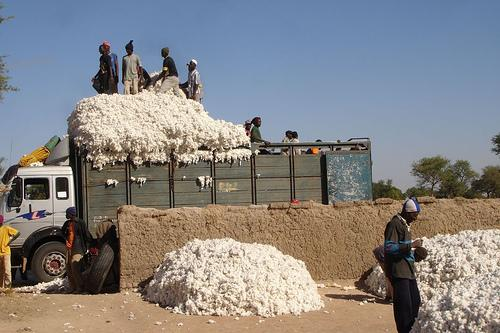

In [ ]:
# Inspect a sample from validation set
sample = val_data[0]
print(sample['caption'])
sample['image']

In [8]:
# Define image preprocessing pipeline
image_processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

def preprocess_sample(sample):
    tokenized = tokenizer(
        sample['caption'],
        padding='max_length',
        truncation=True,
        max_length=MAX_TEXT_LEN,
    )
    sample['input_ids'] = tokenized['input_ids']
    sample['attention_mask'] = tokenized['attention_mask']
    return sample

train_data = train_data.map(preprocess_sample)
val_data = val_data.map(preprocess_sample)
test_data = test_data.map(preprocess_sample)

train_data.set_format(type='torch', columns=['input_ids', 'attention_mask'], output_all_columns=True)
val_data.set_format(type='torch', columns=['input_ids', 'attention_mask'], output_all_columns=True)
test_data.set_format(type='torch', columns=['input_ids', 'attention_mask'], output_all_columns=True)

# Collate function for Dataloader
def collate_fn(batch):
    # Apply image transform and stack into a batch tensor
    pixel_values = image_processor(images=[sample['image'] for sample in batch], return_tensors='pt')['pixel_values']
    captions = [sample['caption'] for sample in batch]
    # Store image filename for retrieval evaluation
    group_ids = [sample['filename'] for sample in batch]

    # Tokenize text captions into input IDs and attention masks
    input_ids = torch.stack([sample['input_ids'] for sample in batch])
    attention_mask = torch.stack([sample['attention_mask'] for sample in batch])

    # Return a dictionary used as model input
    return {
        'pixel_values': pixel_values,
        'captions': captions,
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'group_ids': group_ids,
    }


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/145000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5070 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

In [9]:
# Create DataLoader for train, validation, test sets
train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
)

val_loader = DataLoader(
    val_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
)

test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
)

In [10]:
# Define model architecture and training components
# Projection head to map image/text features into a shared embedding space
class ProjectionHead(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, output_dim),
            nn.GELU(),
            nn.Linear(output_dim, output_dim),
        )

    def forward(self, x):
        return self.net(x)

# image encoder: pretrained ViT-Base
image_encoder = ViTModel.from_pretrained('google/vit-base-patch16-224')
image_encoder = image_encoder.to(device)

# text encoder: pretrained BERT
text_encoder = AutoModel.from_pretrained('bert-base-uncased')
text_encoder = text_encoder.to(device)

# Projection heads
image_projection = ProjectionHead(768, PROJECTION_DIM).to(device)
text_projection = ProjectionHead(768, PROJECTION_DIM).to(device)

# Learnable temperature parameter for contrastive loss scaling
log_temperature = nn.Parameter(torch.log(torch.tensor(1.0 / TEMPERATURE_INIT, device=device)))

# Optionally freeze pretrained encoders to reduce training cost
if FREEZE_BACKBONES:
    for param in image_encoder.parameters():
        param.requires_grad = False
    for param in text_encoder.parameters():
        param.requires_grad = False

# Collect parameters to train
trainable_params = (
    list(image_projection.parameters()) +
    list(text_projection.parameters()) +
    [log_temperature]
)

if not FREEZE_BACKBONES:
    trainable_params += (
        list(image_encoder.parameters()) +
        list(text_encoder.parameters())
    )

# Define optimizer: Adam
optimizer = torch.optim.AdamW(trainable_params, lr=LR, weight_decay=WEIGHT_DECAY)

print('trainable parameter groups ready!')

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


trainable parameter groups ready!


In [11]:
# Encode a batch of data into normalized iamge and text embeddings
def encode_batch(batch):
    pixel_values = batch['pixel_values'].to(device, non_blocking=True)
    input_ids = batch['input_ids'].to(device, non_blocking=True)
    attention_mask = batch['attention_mask'].to(device, non_blocking=True)

    if FREEZE_BACKBONES:
        # Set to evaluation mode - disable dropout, batchnorm...
        image_encoder.eval()
        text_encoder.eval()
        with torch.no_grad():
            image_outputs = image_encoder(pixel_values=pixel_values)
            image_features = image_outputs.last_hidden_state[:, 0, :]
            text_outputs = text_encoder(input_ids=input_ids, attention_mask=attention_mask)
            # use CLS token represent as text embedding
            text_features = text_outputs.last_hidden_state[:, 0, :]
    else:
        # train mode
        image_encoder.train()
        text_encoder.train()
        image_outputs = image_encoder(pixel_values=pixel_values)
        image_features = image_outputs.last_hidden_state[:, 0, :]
        text_outputs = text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        text_features = text_outputs.last_hidden_state[:, 0, :]

    # Project features into shared embedding space
    image_embeds = F.normalize(image_projection(image_features), dim=-1)
    text_embeds = F.normalize(text_projection(text_features), dim=-1)
    return image_embeds, text_embeds


def contrastive_loss(image_embeds, text_embeds):
    # teperature scales similarity scores
    temperature = log_temperature.exp().clamp(min=1e-3, max=100.0)
    # compute similarity matrix between all image-text pairs
    # Shape [batch size, batch size]
    logits = (image_embeds @ text_embeds.T) * temperature
    # Ground truth labels: correct pairs are on the diagonal
    labels = torch.arange(logits.size(0), device=device)
    loss_i2t = F.cross_entropy(logits, labels)
    loss_t2i = F.cross_entropy(logits.T, labels)
    loss = 0.5 * (loss_i2t + loss_t2i)
    return loss, logits

# Compute retrieval performance using Recall @K metrics
@torch.no_grad()
def compute_recall_metrics(image_embeds, text_embeds, group_ids, ks=(1, 5, 10)):
    similarity = text_embeds @ image_embeds.T
    metrics = {}

    group_to_indices = {}
    for idx, group_id in enumerate(group_ids):
        if group_id not in group_to_indices:
            group_to_indices[group_id] = []
        group_to_indices[group_id].append(idx)

    def grouped_recall_at_k(ranking):
        recalls = {}
        for k in ks:
            total_recall = 0.0
            for i in range(len(group_ids)):
                correct_indices = set(group_to_indices[group_ids[i]])
                topk = set(ranking[i, :k].tolist())
                total_recall += len(topk & correct_indices) / len(correct_indices)
            recalls[k] = total_recall / len(group_ids)
        return recalls

    def unique_recall_at_k(score_matrix):
        recalls = {}
        unique_indices = []
        seen_groups = set()
        for idx, group_id in enumerate(group_ids):
            if group_id not in seen_groups:
                seen_groups.add(group_id)
                unique_indices.append(idx)

        unique_scores = score_matrix[unique_indices][:, unique_indices]
        unique_ranking = unique_scores.argsort(dim=1, descending=True)
        for k in ks:
            hits = []
            for i in range(len(unique_indices)):
                topk = unique_ranking[i, :k].tolist()
                hits.append(i in topk)
            recalls[k] = sum(hits) / len(hits)
        return recalls

    ranking_t2i = similarity.argsort(dim=1, descending=True)
    grouped_t2i = grouped_recall_at_k(ranking_t2i)
    unique_t2i = unique_recall_at_k(similarity)

    ranking_i2t = similarity.T.argsort(dim=1, descending=True)
    grouped_i2t = grouped_recall_at_k(ranking_i2t)
    unique_i2t = unique_recall_at_k(similarity.T)

    for k in ks:
        metrics[f"t2i_r@{k}"] = grouped_t2i[k]
        metrics[f"i2t_r@{k}"] = grouped_i2t[k]
        metrics[f"unique_t2i_r@{k}"] = unique_t2i[k]
        metrics[f"unique_i2t_r@{k}"] = unique_i2t[k]

    metrics["grouped_mean_recall"] = float((sum(grouped_t2i.values()) + sum(grouped_i2t.values())) / (2 * len(ks)))
    metrics["unique_mean_recall"] = float((sum(unique_t2i.values()) + sum(unique_i2t.values())) / (2 * len(ks)))
    metrics["mean_recall"] = metrics["grouped_mean_recall"]
    return metrics

# Evaluate the model on a validation or test split
@torch.no_grad()
def validate(dataloader, split_name='validation', mode='all'):
    # Switch all model components to evaluation mode
    image_projection.eval()
    text_projection.eval()
    image_encoder.eval()
    text_encoder.eval()

    all_image_embeds = []
    all_text_embeds = []
    all_group_ids = []

    # Iterate over dataLoader and encode each batch
    # Collect image embeddings, text embeddings, and group IDs across batches
    for batch in tqdm(dataloader, desc=f'Validating {split_name}', leave=False):
        image_embeds, text_embeds = encode_batch(batch)
        all_image_embeds.append(image_embeds)
        all_text_embeds.append(text_embeds)
        all_group_ids.extend(batch["group_ids"])

    all_image_embeds = torch.cat(all_image_embeds, dim=0)
    all_text_embeds = torch.cat(all_text_embeds, dim=0)

    # COmpute retrieval metrics
    metrics = compute_recall_metrics(
        all_image_embeds,
        all_text_embeds,
        all_group_ids,
        ks=(1, 5, 10),
    )

    if mode == 'grouped':
        grouped_metrics = {f't2i_r@{k}': metrics[f't2i_r@{k}'] for k in (1, 5, 10)}
        grouped_metrics.update({f'i2t_r@{k}': metrics[f'i2t_r@{k}'] for k in (1, 5, 10)})
        grouped_metrics['grouped_mean_recall'] = metrics['grouped_mean_recall']
        grouped_metrics['mean_recall'] = metrics['grouped_mean_recall']
        return grouped_metrics

    if mode == 'unique':
        unique_metrics = {f'unique_t2i_r@{k}': metrics[f'unique_t2i_r@{k}'] for k in (1, 5, 10)}
        unique_metrics.update({f'unique_i2t_r@{k}': metrics[f'unique_i2t_r@{k}'] for k in (1, 5, 10)})
        unique_metrics['unique_mean_recall'] = metrics['unique_mean_recall']
        return unique_metrics

    return metrics

In [ ]:
# Sanity check: run a single batch through pipeline
batch = next(iter(train_loader))
image_embeds, text_embeds = encode_batch(batch)
loss, logits = contrastive_loss(image_embeds, text_embeds)

print('image_embeds:', image_embeds.shape)
print('text_embeds:', text_embeds.shape)
print('logits:', logits.shape)
print('loss:', loss.item())

image_embeds: torch.Size([128, 256])
text_embeds: torch.Size([128, 256])
logits: torch.Size([128, 128])
loss: 5.073115348815918


In [ ]:
# Full training loop
best_val = -1.0
history = []

for epoch in range(1, NUM_EPOCHS + 1):
    image_projection.train()
    text_projection.train()
    if not FREEZE_BACKBONES:
        image_encoder.train()
        text_encoder.train()

    running_loss = 0.0

    progress = tqdm(train_loader, desc=f'Epoch {epoch}/{NUM_EPOCHS}')

    # batch training
    for batch in progress:
        optimizer.zero_grad(set_to_none=True)

        image_embeds, text_embeds = encode_batch(batch)
        loss, _ = contrastive_loss(image_embeds, text_embeds)

        loss.backward() # backpropagation
        optimizer.step() # update parameters

        running_loss += loss.item() # accumulate batch loss
        progress.set_postfix(loss=f'{loss.item():.4f}')

    avg_train_loss = running_loss / len(train_loader)
    # Evaluate model performance
    val_metrics = validate(val_loader, split_name='validation')
    epoch_log = {'epoch': epoch, 'train_loss': avg_train_loss, **val_metrics}
    history.append(epoch_log)

    print(epoch_log)

    # Save model if validation performance improves
    if val_metrics['mean_recall'] > best_val:
        best_val = val_metrics['mean_recall']
        checkpoint = {
            'epoch': epoch,
            'image_encoder': image_encoder.state_dict(),
            'text_encoder': text_encoder.state_dict(),
            'image_projection': image_projection.state_dict(),
            'text_projection': text_projection.state_dict(),
            'log_temperature': log_temperature.detach().cpu(),
            'val_metrics': val_metrics,
            'config': {
                'projection_dim': PROJECTION_DIM,
                'max_text_len': MAX_TEXT_LEN,
                'freeze_backbones': FREEZE_BACKBONES,
            },
        }
        torch.save(checkpoint, OUTPUT_DIR / 'best_baseline.pt')
        print('saved best checkpoint to', OUTPUT_DIR / 'best_baseline.pt')

history

Epoch 1/10:   0%|          | 0/1133 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79f9522a0680>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79f9522a0680>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Validating validation:   0%|          | 0/40 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 2.121788826645315, 't2i_r@1': 0.21420118343195266, 't2i_r@10': 0.3268244575936884, 't2i_r@20': 0.4522682445759369, 'i2t_r@1': 0.28205128205128205, 'i2t_r@10': 0.7307692307692307, 'i2t_r@20': 0.8284023668639053, 'mean_recall': 0.47241946088099934}
saved best checkpoint to /content/baseline_outputs/best_baseline.pt


Epoch 2/10:   0%|          | 0/1133 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79f9522a0680>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
     ^  ^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79f9522a0680>^^
^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__

AssertionError    self._shutdown_workers(): 
can only test a child process  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 169

{'epoch': 7, 'train_loss': 0.8579257645127212, 't2i_r@1': 0.27140039447731756, 't2i_r@10': 0.39289940828402364, 't2i_r@20': 0.5295857988165681, 'i2t_r@1': 0.358974358974359, 'i2t_r@10': 0.7909270216962525, 'i2t_r@20': 0.8806706114398422, 'mean_recall': 0.5374095989480605}


Epoch 8/10:   0%|          | 0/1133 [00:00<?, ?it/s]

Exception ignored in: Exception ignored in: Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79f9522a0680><function _MultiProcessingDataLoaderIter.__del__ at 0x79f9522a0680><function _MultiProcessingDataLoaderIter.__del__ at 0x79f9522a0680><function _MultiProcessingDataLoaderIter.__del__ at 0x79f9522a0680>



Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
        self._shutdown_workers()    self._shutdown_workers()    
self._shutdown_workers(

KeyboardInterrupt: 

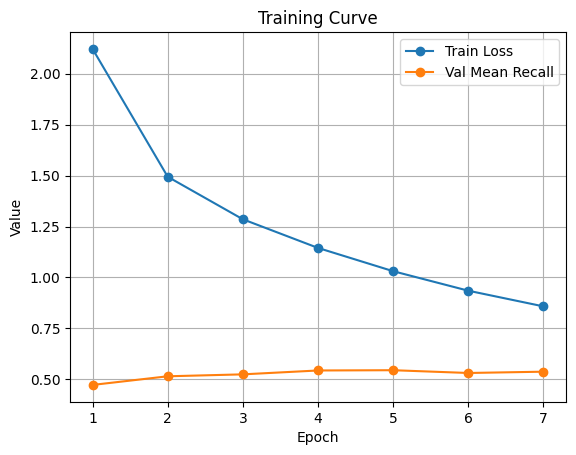

In [ ]:
# Training Loss figure
import matplotlib.pyplot as plt

epochs = [h['epoch'] for h in history]
train_loss = [h['train_loss'] for h in history]
val_recall = [h['mean_recall'] for h in history]

plt.figure()
plt.plot(epochs, train_loss, marker='o', label='Train Loss')
plt.plot(epochs, val_recall, marker='o', label='Val Mean Recall')

plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Training Curve')
plt.legend()
plt.grid(True)
plt.show()

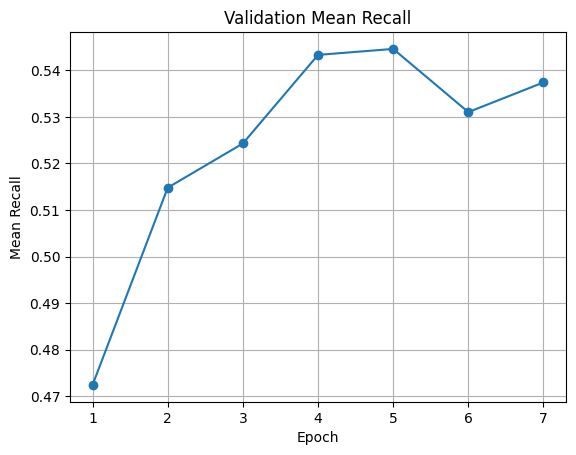

In [ ]:
# Validation Mean Recall
val_recall = [h['mean_recall'] for h in history]

plt.figure()
plt.plot(epochs, val_recall, marker='o')
plt.title('Validation Mean Recall')
plt.xlabel('Epoch')
plt.ylabel('Mean Recall')
plt.grid(True)
plt.show()

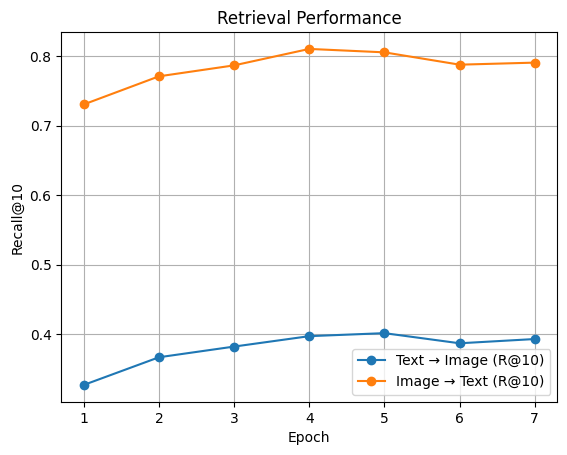

In [ ]:
# t2i vs i2t
t2i = [h['t2i_r@10'] for h in history]
i2t = [h['i2t_r@10'] for h in history]

plt.figure()
plt.plot(epochs, t2i, marker='o', label='Text → Image (R@10)')
plt.plot(epochs, i2t, marker='o', label='Image → Text (R@10)')

plt.title('Retrieval Performance')
plt.xlabel('Epoch')
plt.ylabel('Recall@10')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
!pip install -q huggingface_hub

from huggingface_hub import login, HfApi
login()

api = HfApi()
repo_id = "Zoe3324/flickr30k-baseline"
hf_model_tag = "gelu_freeze_proj256_bs128_lr1e-4_epoch6_ViT_numw4"
hf_filename = f"best_baseline_{hf_model_tag}.pt" if hf_model_tag else "best_baseline.pt"
api.create_repo(repo_id=repo_id, repo_type="model", exist_ok=True)

api.upload_file(
    path_or_fileobj=str(OUTPUT_DIR / "best_baseline.pt"),
    path_in_repo=hf_filename,
    repo_id=repo_id,
    repo_type="model",
)

print(f"uploaded to {repo_id}/{hf_filename}")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ..._outputs/best_baseline.pt:   2%|1         | 15.7MB /  786MB            

uploaded to Zoe3324/flickr30k-baseline/best_baseline_gelu_freeze_proj256_bs128_lr1e-4_epoch6_ViT_numw4.pt


In [12]:
# Load best saved model checkpoint and evaluate
from huggingface_hub import hf_hub_download
import torch

repo_id = "Zoe3324/flickr30k-baseline"
hf_model_tag = "gelu_freeze_proj256_bs128_lr1e-4_epoch6_ViT_numw4"
hf_filename = f"best_baseline_{hf_model_tag}.pt" if hf_model_tag else "best_baseline.pt"

ckpt_path = hf_hub_download(
    repo_id=repo_id,
    filename=hf_filename,
    repo_type="model",
)

best_checkpoint = torch.load(ckpt_path, map_location=device)

# Restore model weights
image_encoder.load_state_dict(best_checkpoint["image_encoder"])
text_encoder.load_state_dict(best_checkpoint["text_encoder"])
image_projection.load_state_dict(best_checkpoint["image_projection"])
text_projection.load_state_dict(best_checkpoint["text_projection"])
# Restore learned temperature parameter
log_temperature.data = best_checkpoint["log_temperature"].to(device)

# Evaluate grouped metrics on test set
grouped_test_metrics = validate(test_loader, split_name="test", mode="grouped")
print(grouped_test_metrics)

best_baseline_gelu_freeze_proj256_bs128_(…):   0%|          | 0.00/786M [00:00<?, ?B/s]

Validating test:   0%|          | 0/40 [00:00<?, ?it/s]

{'t2i_r@1': 0.05351999999999867, 't2i_r@5': 0.2676, 't2i_r@10': 0.3882, 'i2t_r@1': 0.07339999999999755, 'i2t_r@5': 0.2708000000000068, 'i2t_r@10': 0.39740000000000436, 'grouped_mean_recall': 0.24182000000000123, 'mean_recall': 0.24182000000000123}


In [13]:
# Evaluate unique 1-to-1 metrics on test set
unique_test_metrics = validate(test_loader, split_name="test", mode="unique")
print(unique_test_metrics)

Validating test:   0%|          | 0/40 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a752d424680>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
     Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x7a752d424680> 
^Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^    ^self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^    Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7a752d424680>if w.is_alive():
^Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py

{'unique_t2i_r@1': 0.285, 'unique_t2i_r@5': 0.628, 'unique_t2i_r@10': 0.74, 'unique_i2t_r@1': 0.29, 'unique_i2t_r@5': 0.632, 'unique_i2t_r@10': 0.735, 'unique_mean_recall': 0.5516666666666666}
